In [1]:
import numpy as np

In [2]:
np.random.seed(1)
 
trupe_p = 0.7 #we are taking p
data = np.random.binomial(1, trupe_p, 10)
 
print("observed coin tosses (1 = Head, 0 = Tail):")
print(data)
print("number of heads:", data.sum())
 

observed coin tosses (1 = Head, 0 = Tail):
[1 0 1 1 1 1 1 1 1 1]
number of heads: 9


In [3]:
# Now assume coin toss follows a bernoulli distribution, P(x=1)=p, P(X=0)=1-p
#log liklihood function for b d
def log_liklihood(p, data):
    return np.sum(data*np.log(p) + (1-data)*np.log(1-p))

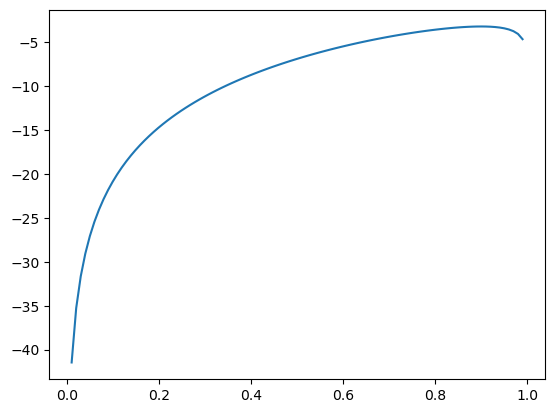

In [5]:
import matplotlib.pyplot as plt
p_values = np.linspace(0.01, 0.99, 100)
ll_values = [log_liklihood(p, data) for p in p_values]
plt.plot(p_values, ll_values)

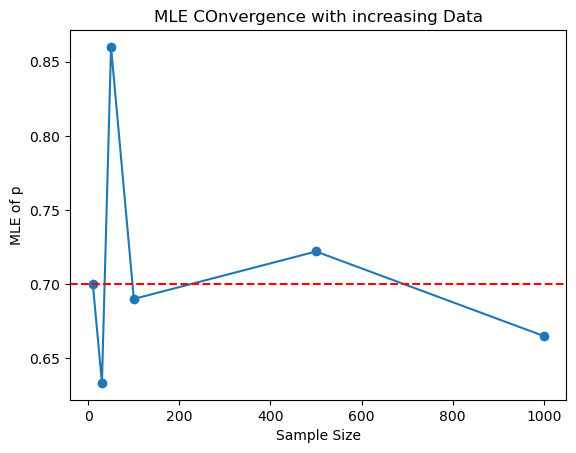

In [7]:
np.random.seed(0)

true_p =0.7
sample_sizes =[10, 30, 50, 100, 500, 1000]
p_mle_values=[]

for n in sample_sizes:
    data=np.random.binomial(1, true_p, n)
    p_mle = data.mean()
    p_mle_values.append(p_mle)


#plot
plt.plot(sample_sizes, p_mle_values, marker='o')
plt.axhline(y=true_p, color='r', linestyle='--',)
plt.xlabel('Sample Size')
plt.ylabel('MLE of p')
plt.title('MLE COnvergence with increasing Data')
plt.show()



Generate Normal Data (True μ, σ)

In [8]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1)

true_mu = 5
true_sigma = 2
n = 1000

data = np.random.normal(true_mu, true_sigma, n)

print("True mean:", true_mu)
print("True std:", true_sigma)



True mean: 5
True std: 2


Estimate Mean and Std from Dataset (MLE)

In [9]:
mu_mle = np.mean(data)
sigma_mle = np.sqrt(np.mean((data - mu_mle) ** 2))

print("Estimated mean (MLE):", mu_mle)
print("Estimated std (MLE):", sigma_mle)



Estimated mean (MLE): 5.077624952319204
Estimated std (MLE): 1.9620082678644233


Log-Likelihood Function (Normal Distribution)


In [10]:
def log_likelihood(mu, sigma, data):
    n = len(data)
    return -n*np.log(sigma*np.sqrt(2*np.pi)) - np.sum((data - mu)**2) / (2*sigma**2)


 Log-Likelihood vs Mean (σ fixed)


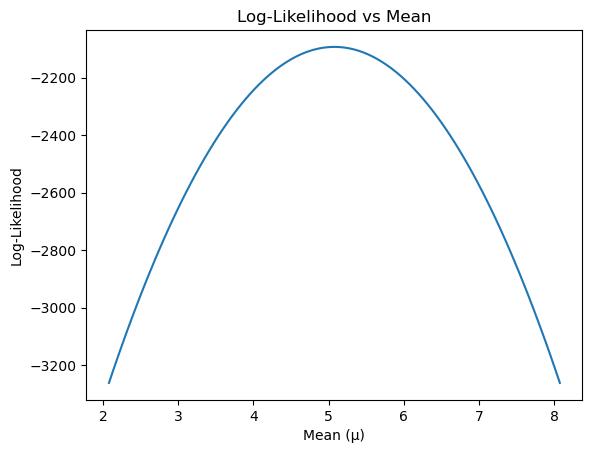

In [11]:
mu_values = np.linspace(mu_mle - 3, mu_mle + 3, 100)
ll_values = [log_likelihood(mu, sigma_mle, data) for mu in mu_values]

plt.plot(mu_values, ll_values)
plt.xlabel("Mean (μ)")
plt.ylabel("Log-Likelihood")
plt.title("Log-Likelihood vs Mean")
plt.show()


Log-Likelihood vs Std (μ fixed)

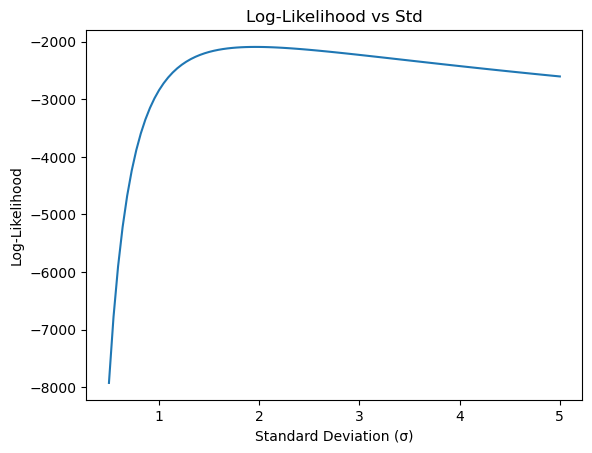

In [12]:
sigma_values = np.linspace(0.5, 5, 100)
ll_sigma = [log_likelihood(mu_mle, s, data) for s in sigma_values]

plt.plot(sigma_values, ll_sigma)
plt.xlabel("Standard Deviation (σ)")
plt.ylabel("Log-Likelihood")
plt.title("Log-Likelihood vs Std")
plt.show()


Checking Convergence of MLE (Increasing Sample Size)

In [13]:
np.random.seed(0)

sample_sizes = [10, 30, 50, 100, 500, 1000]
mu_mle_values = []
sigma_mle_values = []

for n in sample_sizes:
    data = np.random.normal(true_mu, true_sigma, n)
    mu_hat = np.mean(data)
    sigma_hat = np.sqrt(np.mean((data - mu_hat) ** 2))
    
    mu_mle_values.append(mu_hat)
    sigma_mle_values.append(sigma_hat)


📈 Mean Convergence


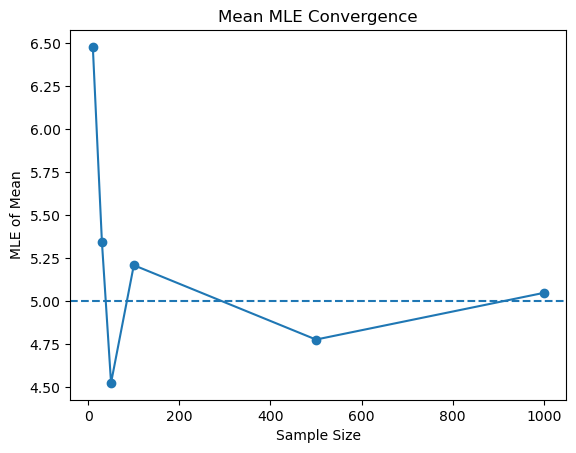

In [14]:
plt.plot(sample_sizes, mu_mle_values, marker='o')
plt.axhline(true_mu, linestyle='--')
plt.xlabel("Sample Size")
plt.ylabel("MLE of Mean")
plt.title("Mean MLE Convergence")
plt.show()


Std Convergence

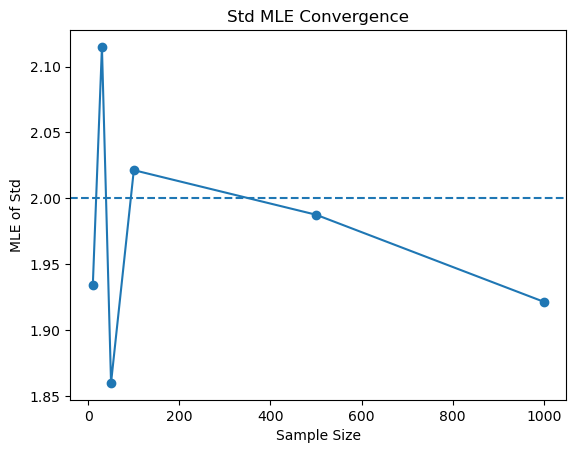

In [15]:
plt.plot(sample_sizes, sigma_mle_values, marker='o')
plt.axhline(true_sigma, linestyle='--')
plt.xlabel("Sample Size")
plt.ylabel("MLE of Std")
plt.title("Std MLE Convergence")
plt.show()
